In [ ]:
!pip -q install sacrebleu nltk sentencepiece


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.0/128.0 kB 14.5 MB/s eta 0:00:00


In [ ]:
import os
import re
import math
import time
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sacrebleu

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import (
    pad_sequence,
    pack_padded_sequence,
    pad_packed_sequence
)

from tqdm.auto import tqdm

#from google.colab import drive
#drive.mount('/content/drive')

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)
print("PyTorch:", torch.__version__)

Device: cuda
PyTorch: 2.11.0+cu128


In [ ]:
ARABIC_DIACRITICS = re.compile(
    r'[\u064B-\u065F\u0670\u06D6-\u06ED]'
)


def normalize_arabic(text):

    text = text.strip()

    text = ARABIC_DIACRITICS.sub('', text)

    text = text.replace('أ', 'ا')
    text = text.replace('إ', 'ا')
    text = text.replace('آ', 'ا')
    text = text.replace('ى', 'ي')
    text = text.replace('ة', 'ه')
    text = text.replace('ـ', '')

    text = re.sub(
        r'([.!?؟،,])',
        r' \1 ',
        text
    )

    text = re.sub(r'\s+', ' ', text).strip()

    return text


def normalize_english(text):

    text = text.lower().strip()

    text = re.sub(
        r"([.!?,])",
        r' \1 ',
        text
    )

    text = re.sub(
        r"[^a-z0-9.!?,'\s]",
        '',
        text
    )

    text = re.sub(r'\s+', ' ', text).strip()

    return text


def tokenize(text):
    return text.split()

In [ ]:

!pip install -q opustools

!opus_read -d Wikipedia -s ar -t en -w wikipedia_ar.txt wikipedia_en.txt -wm moses


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 10.4 MB/s eta 0:00:00
No alignment file "/projappl/nlpl/data/OPUS/Wikipedia/latest/xml/ar-en.xml.gz" or "./Wikipedia_latest_xml_ar-en.xml.gz" found
The following files are available for downloading:

   1 MB https://object.pouta.csc.fi/OPUS-Wikipedia/v1.0/xml/ar-en.xml.gz | 1 documents, 151136 alignment pairs, 3162547 source tokens, 3509577 target tokens (id 581570)
 156 MB https://object.pouta.csc.fi/OPUS-Wikipedia/v1.0/xml/ar.zip | 3 documents, 974851 sentences, 24909466 tokens (id 581717)
   4 GB https://object.pouta.csc.fi/OPUS-Wikipedia/v1.0/xml/en.zip | 39 documents, 10736187 sentences, 275815008 tokens (id 581742)

   4 GB Total size
./Wikipedia_latest_xml_ar-en.xml.gz ... 100% of 1 MB
./Wikipedia_latest_xml_ar.zip ... 100% of 156 MB
./Wikipedia_latest_xml_en.zip ... 100% of 4 GB

Parsing file "Wikipedia/xml/ar/wiki0.ar-en.xml" ... 100.0%
Pars

In [ ]:
import re

LATIN_LETTERS_RE = re.compile(r'[A-Za-z]')
ARABIC_LETTERS_RE = re.compile(r'[\u0600-\u06FF]')

def load_pairs_from_opus(en_path, ar_path):
    pairs = []
    skipped_empty = 0
    skipped_mixed = 0

    with open(en_path, "r", encoding="utf-8") as f_en, \
         open(ar_path, "r", encoding="utf-8") as f_ar:

        for en_line, ar_line in zip(f_en, f_ar):
            en_raw = en_line.strip()
            ar_raw = ar_line.strip()

            if not en_raw or not ar_raw:
                skipped_empty += 1
                continue

            # Data cleaning: drop code-mixed pairs
            if LATIN_LETTERS_RE.search(ar_raw) or ARABIC_LETTERS_RE.search(en_raw):
                skipped_mixed += 1
                continue

            en = normalize_english(en_raw)
            ar = normalize_arabic(ar_raw)

            if ar and en:
                pairs.append((ar, en))

    print(f"Skipped {skipped_empty:,} empty pairs")
    print(f"Skipped {skipped_mixed:,} code-mixed pairs (Latin letters in AR side / Arabic letters in EN side)")

    return pairs


pairs = load_pairs_from_opus(
    "wikipedia_en.txt",
    "wikipedia_ar.txt"
)

print(f"Total samples after cleaning: {len(pairs):,}")

# Extra cleaning: Remove exact duplicates
seen = set()
deduped_pairs = []
duplicates = 0

for ar, en in pairs:
    key = (ar, en)
    if key in seen:
        duplicates += 1
        continue
    seen.add(key)
    deduped_pairs.append((ar, en))

pairs = deduped_pairs

print(f"Removed {duplicates:,} exact duplicate pairs")
print(f"Total samples loaded: {len(pairs):,}")

print("\nExamples:")
for ar, en in pairs[:3]:
    print("AR :", ar)
    print("EN :", en)
    print()

Skipped 0 empty pairs
Skipped 62,761 code-mixed pairs (Latin letters in AR side / Arabic letters in EN side)
Total samples after cleaning: 88,366
Removed 2,096 exact duplicate pairs
Total samples loaded: 86,270

Examples:
AR : يحدها من الشمال خليج فنلندا ، ومن الغرب بحر البلطيق ، ومن الجنوب لاتفيا ( 343 كم ) ، والي الشرق من بحيره بيبوس والاتحاد الروسي ( 338 . 6 كم ) .
EN : it is bordered to the north by the gulf of finland , to the west by the baltic sea , to the south by latvia 343 km , and to the east by lake peipus and russia 338 . 6 km .

AR : وعبر بحر البلطيق تقع السويد في الغرب وفنلندا في الشمال .
EN : across the baltic sea lies sweden in the west and finland in the north .

AR : = = = ما قبل التاريخ = = = اصبح استقرار الانسان في استونيا ممكنا قبل حوالي 11 , 000 الي 13 , 000 سنه ، عندما ذاب الجليد من اخر عصر جليدي .
EN : history prehistory human settlement in estonia became possible 11 , 000 to 13 , 000 years ago , when the ice from the last glacial era melted .



## Word Count Distribution

Look at how many words each Arabic / English sentence has before doing any sampling or outlier removal.

Arabic  -> min: 1, max: 484, mean: 20.5, median: 18.0
English -> min: 1, max: 449, mean: 22.4, median: 20.0
Average -> min: 1.0, max: 466.0, mean: 21.4, median: 19.0


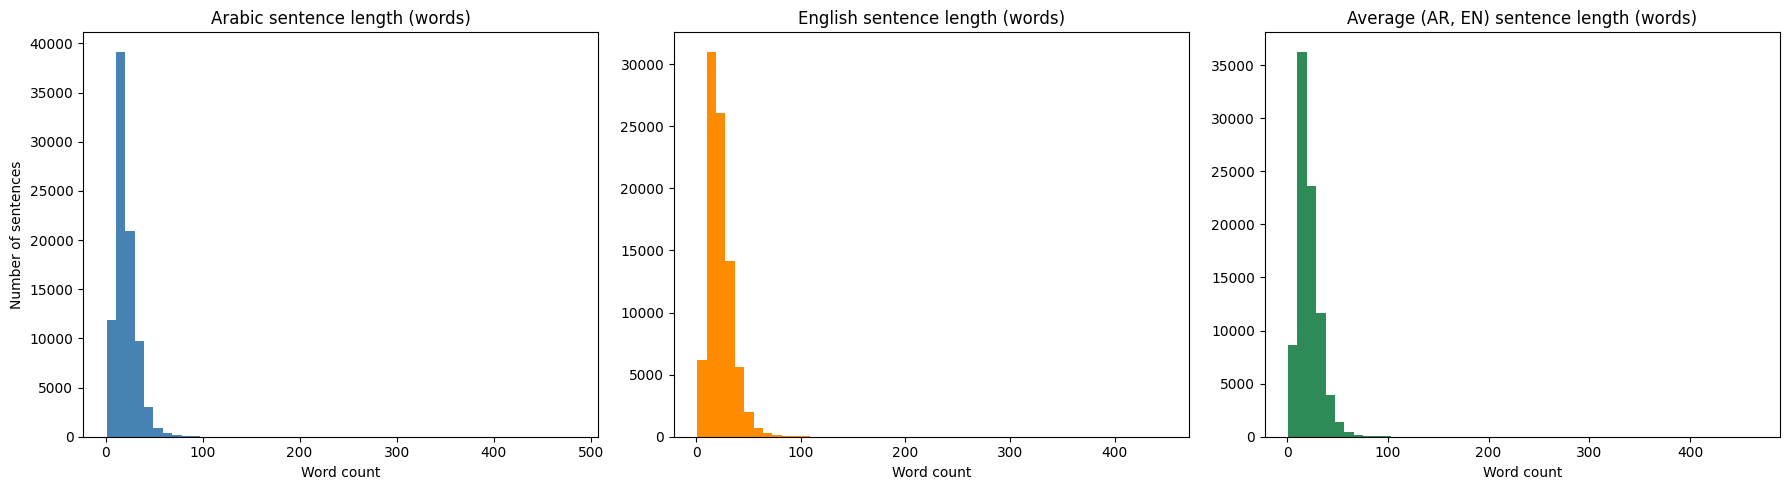

In [ ]:
ar_lens_all = np.array([len(tokenize(ar)) for ar, en in pairs])
en_lens_all = np.array([len(tokenize(en)) for ar, en in pairs])
avg_lens_all = (ar_lens_all + en_lens_all) / 2

print(f"Arabic  -> min: {ar_lens_all.min()}, max: {ar_lens_all.max()}, mean: {ar_lens_all.mean():.1f}, median: {np.median(ar_lens_all):.1f}")
print(f"English -> min: {en_lens_all.min()}, max: {en_lens_all.max()}, mean: {en_lens_all.mean():.1f}, median: {np.median(en_lens_all):.1f}")
print(f"Average -> min: {avg_lens_all.min():.1f}, max: {avg_lens_all.max():.1f}, mean: {avg_lens_all.mean():.1f}, median: {np.median(avg_lens_all):.1f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(ar_lens_all, bins=50, color="steelblue")
axes[0].set_title("Arabic sentence length (words)")
axes[0].set_xlabel("Word count")
axes[0].set_ylabel("Number of sentences")

axes[1].hist(en_lens_all, bins=50, color="darkorange")
axes[1].set_title("English sentence length (words)")
axes[1].set_xlabel("Word count")

axes[2].hist(avg_lens_all, bins=50, color="seagreen")
axes[2].set_title("Average (AR, EN) sentence length (words)")
axes[2].set_xlabel("Word count")

plt.tight_layout()
plt.show()


## Random Sampling (35,000 pairs)

Take a fixed-size random sample before removing outliers, so the outlier-removal step below runs on this subset instead of the full corpus.

In [ ]:
N_SAMPLE = 100_000

if len(pairs) > N_SAMPLE:
    pairs = random.Random(SEED).sample(pairs, N_SAMPLE)
else:
    print(f"Dataset only has {len(pairs):,} pairs, which is <= {N_SAMPLE:,}; keeping all of them.")

print(f"Sample size: {len(pairs):,}")


Dataset only has 86,270 pairs, which is <= 100,000; keeping all of them.
Sample size: 86,270


In [ ]:
def iqr_bounds(values, k=1.5):
    q1, q3 = np.percentile(values, [25, 75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr


MAX_WORDS = 35  # aggressive hard cap: drop any sample where either side is longer than this

ar_lens = np.array([len(tokenize(ar)) for ar, en in pairs])
en_lens = np.array([len(tokenize(en)) for ar, en in pairs])

hard_cap_keep = (ar_lens <= MAX_WORDS) & (en_lens <= MAX_WORDS)
removed_hard_cap = int((~hard_cap_keep).sum())

print(f"Hard cap filter (max {MAX_WORDS} words per side): removed {removed_hard_cap:,} out of {len(pairs):,} "
      f"({removed_hard_cap / len(pairs):.1%})")

pairs = [p for p, keep in zip(pairs, hard_cap_keep) if keep]
print(f"Remaining after hard cap: {len(pairs):,}")

# Recompute lengths after the hard cap, then apply the IQR filter on the
# average length as before. The upper IQR bound is also clipped to
# MAX_WORDS, so the hard cap always wins even if IQR alone would allow
# a higher bound -- this is what makes outlier removal more aggressive.
ar_lens = np.array([len(tokenize(ar)) for ar, en in pairs])
en_lens = np.array([len(tokenize(en)) for ar, en in pairs])
avg_lens = (ar_lens + en_lens) / 2

low, high = iqr_bounds(avg_lens)
low = max(low, 1)            # minimum word length floor = 1
high = min(high, MAX_WORDS)  # never allow the IQR bound above the hard cap

print(f"Average word count bounds: [{low:.1f}, {high:.1f}]  (raw range: {avg_lens.min():.1f}-{avg_lens.max():.1f})")

filtered_pairs = []
removed = 0

for (ar, en), avg_l in zip(pairs, avg_lens):
    if low <= avg_l <= high:
        filtered_pairs.append((ar, en))
    else:
        removed += 1

print(f"Removed {removed:,} outlier pairs out of {len(pairs):,} ({removed / len(pairs):.1%})")
print(f"Remaining: {len(filtered_pairs):,}")

pairs = filtered_pairs


Hard cap filter (max 35 words per side): removed 10,707 out of 86,270 (12.4%)
Remaining after hard cap: 75,563
Average word count bounds: [1.0, 35.0]  (raw range: 1.0-35.0)
Removed 0 outlier pairs out of 75,563 (0.0%)
Remaining: 75,563


In [ ]:
ar_lens = np.array([len(tokenize(ar)) for ar, en in pairs])
en_lens = np.array([len(tokenize(en)) for ar, en in pairs])
en_ar_ratio = en_lens / ar_lens

low, high = iqr_bounds(en_ar_ratio)

print(f"EN/AR ratio bounds: [{low:.2f}, {high:.2f}]  (raw range: {en_ar_ratio.min():.2f}-{en_ar_ratio.max():.2f})")

filtered_pairs = []
removed = 0

for (ar, en), r in zip(pairs, en_ar_ratio):
    if low <= r <= high:
        filtered_pairs.append((ar, en))
    else:
        removed += 1

print(f"Removed {removed:,} outlier pairs out of {len(pairs):,} ({removed / len(pairs):.1%})")
print(f"Remaining: {len(filtered_pairs):,}")

pairs = filtered_pairs

EN/AR ratio bounds: [0.67, 1.56]  (raw range: 0.08-13.00)
Removed 1,851 outlier pairs out of 75,563 (2.4%)
Remaining: 73,712


In [ ]:
random.Random(SEED).shuffle(pairs)

n = len(pairs)

n_train = int(0.94 * n)
n_val   = int(0.03 * n)

train_pairs = pairs[:n_train]
val_pairs   = pairs[n_train:n_train + n_val]
test_pairs  = pairs[n_train + n_val:]

print(f"Train: {len(train_pairs):,}")
print(f"Val  : {len(val_pairs):,}")
print(f"Test : {len(test_pairs):,}")

Train: 69,289
Val  : 2,211
Test : 2,212


In [ ]:
class Vocab:

    PAD, SOS, EOS, UNK = 0, 1, 2, 3

    SPECIALS = [
        "<pad>",
        "<sos>",
        "<eos>",
        "<unk>"
    ]

    def __init__(self, token_lists, min_freq=2):

        counter = Counter()

        for tokens in token_lists:
            counter.update(tokens)

        self.itos = list(self.SPECIALS)

        for token, count in counter.most_common():

            if count >= min_freq:
                self.itos.append(token)

        self.stoi = {
            token: i
            for i, token in enumerate(self.itos)
        }

    def __len__(self):
        return len(self.itos)

    def encode(
        self,
        tokens,
        add_sos=False,
        add_eos=True
    ):

        ids = [
            self.stoi.get(token, self.UNK)
            for token in tokens
        ]

        if add_sos:
            ids = [self.SOS] + ids

        if add_eos:
            ids = ids + [self.EOS]

        return ids

    def decode(self, ids):

        words = []

        for i in ids:

            if i == self.EOS:
                break

            if i in (self.PAD, self.SOS):
                continue

            if i < len(self.itos):
                words.append(self.itos[i])

        return " ".join(words)

In [ ]:
import sentencepiece as spm

# Subword tokenization (BPE) instead of whole-word vocab. This matters a
# lot for Arabic: it's a morphologically rich language (prefixes/suffixes
# stack on a root), so whole-word vocab either explodes in size or turns
# huge numbers of valid words into <unk>. BPE splits rare/unseen words
# into smaller known pieces instead of discarding them, which both keeps
# the vocab small and removes most <unk> tokens at inference time.

SPM_DIR = "/content/spm"
os.makedirs(SPM_DIR, exist_ok=True)

SRC_VOCAB_SIZE = 8000  # Arabic (subword) vocab size
TGT_VOCAB_SIZE = 8000  # English (subword) vocab size


def write_corpus(path, sentences):
    with open(path, "w", encoding="utf-8") as f:
        for s in sentences:
            f.write(s + "\n")


ar_train_txt = f"{SPM_DIR}/train_ar.txt"
en_train_txt = f"{SPM_DIR}/train_en.txt"

write_corpus(ar_train_txt, [ar for ar, _ in train_pairs])
write_corpus(en_train_txt, [en for _, en in train_pairs])

# pad/bos/eos/unk ids are pinned to 0/1/2/3 so they line up exactly with
# Vocab.PAD/SOS/EOS/UNK used everywhere else in the notebook (encoder /
# decoder padding_idx, src_mask, greedy & beam decoding loops, etc.) --
# nothing downstream needs to change because of that.
SPM_TRAIN_ARGS = dict(
    model_type="bpe",
    character_coverage=1.0,
    pad_id=0, bos_id=1, eos_id=2, unk_id=3,
    pad_piece="<pad>", bos_piece="<sos>", eos_piece="<eos>", unk_piece="<unk>",
)

spm.SentencePieceTrainer.train(
    input=ar_train_txt,
    model_prefix=f"{SPM_DIR}/spm_ar",
    vocab_size=SRC_VOCAB_SIZE,
    **SPM_TRAIN_ARGS
)

spm.SentencePieceTrainer.train(
    input=en_train_txt,
    model_prefix=f"{SPM_DIR}/spm_en",
    vocab_size=TGT_VOCAB_SIZE,
    **SPM_TRAIN_ARGS
)


class SPVocab:
    """Thin wrapper so a SentencePiece model can be dropped in wherever
    the old word-level Vocab instances (src_vocab / tgt_vocab) were used."""

    PAD, SOS, EOS, UNK = 0, 1, 2, 3

    def __init__(self, model_path):
        self.sp = spm.SentencePieceProcessor(model_file=model_path)

    def __len__(self):
        return self.sp.get_piece_size()

    def encode(self, text, add_sos=False, add_eos=True):
        ids = self.sp.encode(text, out_type=int)

        if add_sos:
            ids = [self.SOS] + ids

        if add_eos:
            ids = ids + [self.EOS]

        return ids

    def encode_pieces(self, text):
        """Subword piece strings (for attention-plot axis labels only)."""
        return self.sp.encode(text, out_type=str)

    def decode(self, ids):
        clean_ids = []

        for i in ids:
            if i == self.EOS:
                break
            if i in (self.PAD, self.SOS):
                continue
            clean_ids.append(int(i))

        return self.sp.decode(clean_ids)


src_vocab = SPVocab(f"{SPM_DIR}/spm_ar.model")
tgt_vocab = SPVocab(f"{SPM_DIR}/spm_en.model")

print("Arabic subword vocab :", len(src_vocab))
print("English subword vocab:", len(tgt_vocab))


Arabic subword vocab : 8000
English subword vocab: 8000


In [ ]:
WORK_DIR = "/content/nmt_project"
os.makedirs(WORK_DIR, exist_ok=True)


def save_pairs(path, data):

    with open(path, "w", encoding="utf-8") as f:

        for ar, en in data:
            f.write(ar + "\t" + en + "\n")


TRAIN_FILE = f"{WORK_DIR}/train.tsv"
VAL_FILE   = f"{WORK_DIR}/val.tsv"
TEST_FILE  = f"{WORK_DIR}/test.tsv"

save_pairs(TRAIN_FILE, train_pairs)
save_pairs(VAL_FILE, val_pairs)
save_pairs(TEST_FILE, test_pairs)

print("Splits saved.")

Splits saved.


In [ ]:
class LazyNMTDataset(Dataset):

    def __init__(self, path, src_vocab, tgt_vocab):

        self.path = path
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

        self.offsets = []

        with open(path, "rb") as f:

            while True:

                pos = f.tell()
                line = f.readline()

                if not line:
                    break

                self.offsets.append(pos)

    def __len__(self):
        return len(self.offsets)

    def __getitem__(self, idx):

        with open(self.path, "rb") as f:

            f.seek(self.offsets[idx])

            line = f.readline().decode(
                "utf-8"
            ).rstrip("\n")

        ar, en = line.split("\t")

        # NOTE: src_vocab / tgt_vocab are now SentencePiece-backed
        # (SPVocab), so we pass the raw sentence string directly --
        # SentencePiece does its own subword tokenization internally,
        # unlike the old word-level Vocab which needed a pre-tokenized
        # list of words (tokenize(text)).
        src_ids = self.src_vocab.encode(
            ar,
            add_sos=False,
            add_eos=True
        )

        tgt_ids = self.tgt_vocab.encode(
            en,
            add_sos=True,
            add_eos=True
        )

        return (
            torch.tensor(src_ids, dtype=torch.long),
            torch.tensor(tgt_ids, dtype=torch.long)
        )


In [ ]:
def collate_fn(batch):

    src, tgt = zip(*batch)

    src_lens = torch.tensor(
        [len(x) for x in src],
        dtype=torch.long
    )

    src = pad_sequence(
        src,
        batch_first=True,
        padding_value=Vocab.PAD
    )

    tgt = pad_sequence(
        tgt,
        batch_first=True,
        padding_value=Vocab.PAD
    )

    return src, src_lens, tgt

In [ ]:
class RNNEncoder(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_dim,
        enc_hidden,
        dec_hidden,
        dropout
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=Vocab.PAD
        )

        self.rnn = nn.LSTM(
            embed_dim,
            enc_hidden,
            batch_first=True,
            bidirectional=True
        )

        self.fc_h = nn.Linear(
            2 * enc_hidden,
            dec_hidden
        )

        self.fc_c = nn.Linear(
            2 * enc_hidden,
            dec_hidden
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_lens):

        emb = self.dropout(
            self.embedding(src)
        )

        packed = pack_padded_sequence(
            emb,
            src_lens.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        outputs, (h, c) = self.rnn(packed)

        outputs, _ = pad_packed_sequence(
            outputs,
            batch_first=True
        )

        h_cat = torch.cat(
            [h[0], h[1]],
            dim=1
        )

        c_cat = torch.cat(
            [c[0], c[1]],
            dim=1
        )

        h0 = torch.tanh(
            self.fc_h(h_cat)
        ).unsqueeze(0)

        c0 = torch.tanh(
            self.fc_c(c_cat)
        ).unsqueeze(0)

        return outputs, (h0, c0)

In [ ]:
class BahdanauAttention(nn.Module):

    def __init__(
        self,
        enc_hidden,
        dec_hidden,
        attn_dim
    ):
        super().__init__()

        self.W_enc = nn.Linear(
            2 * enc_hidden,
            attn_dim,
            bias=False
        )

        self.W_dec = nn.Linear(
            dec_hidden,
            attn_dim,
            bias=False
        )

        self.v = nn.Linear(
            attn_dim,
            1,
            bias=False
        )

    def forward(
        self,
        dec_h,
        enc_outputs,
        src_mask
    ):

        enc_proj = self.W_enc(
            enc_outputs
        )

        dec_proj = self.W_dec(
            dec_h
        ).unsqueeze(1)

        scores = self.v(
            torch.tanh(
                enc_proj + dec_proj
            )
        ).squeeze(-1)

        scores = scores.masked_fill(
            ~src_mask,
            float("-inf")
        )

        weights = torch.softmax(
            scores,
            dim=-1
        )

        context = torch.bmm(
            weights.unsqueeze(1),
            enc_outputs
        ).squeeze(1)

        return context, weights

In [ ]:
class RNNDecoder(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_dim,
        enc_hidden,
        dec_hidden,
        attn_dim,
        dropout
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=Vocab.PAD
        )

        self.attn = BahdanauAttention(
            enc_hidden,
            dec_hidden,
            attn_dim
        )

        self.rnn = nn.LSTM(
            embed_dim + 2 * enc_hidden,
            dec_hidden,
            batch_first=True
        )

        self.fc_out = nn.Linear(
            dec_hidden +
            2 * enc_hidden +
            embed_dim,
            vocab_size
        )

        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        tgt_step,
        hidden,
        enc_outputs,
        src_mask
    ):

        emb = self.dropout(
            self.embedding(tgt_step)
        ).unsqueeze(1)

        context, attn_w = self.attn(
            hidden[0].squeeze(0),
            enc_outputs,
            src_mask
        )

        rnn_input = torch.cat(
            [
                emb,
                context.unsqueeze(1)
            ],
            dim=-1
        )

        out, hidden = self.rnn(
            rnn_input,
            hidden
        )

        out = out.squeeze(1)

        logits = self.fc_out(
            torch.cat(
                [
                    out,
                    context,
                    emb.squeeze(1)
                ],
                dim=-1
            )
        )

        return logits, hidden, attn_w

In [ ]:
class Seq2SeqRNN(nn.Module):

    def __init__(
        self,
        encoder,
        decoder
    ):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder

    def forward(
        self,
        src,
        src_lens,
        tgt,
        teacher_forcing_ratio=1.0
    ):

        B, T = tgt.shape

        vocab_size = (
            self.decoder.fc_out.out_features
        )

        src_mask = (
            src != Vocab.PAD
        )

        enc_outputs, hidden = self.encoder(
            src,
            src_lens
        )

        outputs = torch.zeros(
            B,
            T,
            vocab_size,
            device=src.device
        )

        input_step = tgt[:, 0]

        for t in range(1, T):

            logits, hidden, _ = self.decoder(
                input_step,
                hidden,
                enc_outputs,
                src_mask
            )

            outputs[:, t] = logits

            use_tf = (
                random.random()
                < teacher_forcing_ratio
            )

            input_step = (
                tgt[:, t]
                if use_tf
                else logits.argmax(-1)
            )

        return outputs

    @torch.no_grad()
    def greedy_decode(
        self,
        src,
        src_lens,
        max_len=30
    ):

        self.eval()

        src_mask = (
            src != Vocab.PAD
        )

        enc_outputs, hidden = self.encoder(
            src,
            src_lens
        )

        input_step = torch.full(
            (src.size(0),),
            Vocab.SOS,
            dtype=torch.long,
            device=src.device
        )

        tokens = []

        for _ in range(max_len):

            logits, hidden, _ = self.decoder(
                input_step,
                hidden,
                enc_outputs,
                src_mask
            )

            preds = logits.argmax(-1)

            tokens.append(preds)

            input_step = preds

        return torch.stack(
            tokens,
            dim=1
        )

In [ ]:
EMBED_DIM = 128
ENC_HIDDEN = 192
DEC_HIDDEN = 256
ATTN_DIM = 192
DROPOUT = 0.4

encoder = RNNEncoder(
    len(src_vocab),
    EMBED_DIM,
    ENC_HIDDEN,
    DEC_HIDDEN,
    DROPOUT
)

decoder = RNNDecoder(
    len(tgt_vocab),
    EMBED_DIM,
    ENC_HIDDEN,
    DEC_HIDDEN,
    ATTN_DIM,
    DROPOUT
)

model = Seq2SeqRNN(
    encoder,
    decoder
).to(device)

params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Trainable parameters: {params:,}")

Trainable parameters: 9,803,264


In [ ]:
EPOCHS = 40
LR = 7e-4
WEIGHT_DECAY = 1e-5
CLIP = 1.0
PATIENCE = 3

criterion = nn.CrossEntropyLoss(
    ignore_index=Vocab.PAD,
    label_smoothing=0.1
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=1
)

In [ ]:
def train_epoch(model, loader, teacher_forcing_ratio=1.0):

    model.train()

    total_loss = 0

    for src, src_lens, tgt in tqdm(
        loader,
        desc="Train",
        leave=False
    ):

        src = src.to(
            device,
            non_blocking=True
        )

        tgt = tgt.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        output = model(
            src,
            src_lens,
            tgt,
            teacher_forcing_ratio=teacher_forcing_ratio
        )

        output = output[:, 1:].reshape(
            -1,
            output.size(-1)
        )

        target = tgt[:, 1:].reshape(-1)

        loss = criterion(
            output,
            target
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            CLIP
        )

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate_loss(model, loader):

    # Validation loss is always measured with full teacher forcing
    # (ratio=1.0) so it stays a consistent, comparable metric across
    # epochs, independent of the scheduled-sampling ratio used in
    # training that epoch.

    model.eval()

    total_loss = 0

    for src, src_lens, tgt in tqdm(
        loader,
        desc="Val",
        leave=False
    ):

        src = src.to(
            device,
            non_blocking=True
        )

        tgt = tgt.to(
            device,
            non_blocking=True
        )

        output = model(
            src,
            src_lens,
            tgt,
            teacher_forcing_ratio=1.0
        )

        output = output[:, 1:].reshape(
            -1,
            output.size(-1)
        )

        target = tgt[:, 1:].reshape(-1)

        loss = criterion(
            output,
            target
        )

        total_loss += loss.item()

    return total_loss / len(loader)


In [ ]:
BATCH_SIZE = 64

train_ds = LazyNMTDataset(
    TRAIN_FILE,
    src_vocab,
    tgt_vocab
)

val_ds = LazyNMTDataset(
    VAL_FILE,
    src_vocab,
    tgt_vocab
)

test_ds = LazyNMTDataset(
    TEST_FILE,
    src_vocab,
    tgt_vocab
)


train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True
)

print("Train:", len(train_ds))
print("Val  :", len(val_ds))
print("Test :", len(test_ds))
print("Train batches:", len(train_loader))

Train: 69289
Val  : 2211
Test : 2212
Train batches: 1083


In [ ]:
history = {
    "train": [],
    "val": []
}

best_val = float("inf")
bad_epochs = 0


MIN_TEACHER_FORCING = 0.5

for epoch in range(1, EPOCHS + 1):

    start = time.time()

    tf_ratio = max(
        MIN_TEACHER_FORCING,
        1.0 - (epoch - 1) * (1.0 - MIN_TEACHER_FORCING) / max(1, EPOCHS - 1)
    )

    train_loss = train_epoch(
        model,
        train_loader,
        teacher_forcing_ratio=tf_ratio
    )

    val_loss = evaluate_loss(
        model,
        val_loader
    )

    scheduler.step(val_loss)

    history["train"].append(train_loss)
    history["val"].append(val_loss)

    lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch:02d} | "
        f"Train: {train_loss:.4f} | "
        f"Val: {val_loss:.4f} | "
        f"TF: {tf_ratio:.2f} | "
        f"LR: {lr:.1e} | "
        f"Time: {time.time()-start:.1f}s"
    )

    if val_loss < best_val:

        best_val = val_loss
        bad_epochs = 0

        torch.save(
            model.state_dict(),
            f"{WORK_DIR}/best_model.pt"
        )

    else:

        bad_epochs += 1

        if bad_epochs >= PATIENCE:

            print("Early stopping.")
            break


model.load_state_dict(
    torch.load(
        f"{WORK_DIR}/best_model.pt",
        map_location=device
    )
)

print(f"Best validation loss: {best_val:.4f}")


Train:   0%|          | 0/1083 [00:00<?, ?it/s]

Val:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 01 | Train: 6.1817 | Val: 5.6320 | TF: 1.00 | LR: 7.0e-04 | Time: 201.8s


Train:   0%|          | 0/1083 [00:00<?, ?it/s]

Val:   0%|          | 0/35 [00:00<?, ?it/s]

...

Val:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 31 | Train: 3.7646 | Val: 3.7337 | TF: 0.62 | LR: 8.7e-05 | Time: 200.3s


Train:   0%|          | 0/1083 [00:00<?, ?it/s]

Val:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 32 | Train: 3.7538 | Val: 3.7326 | TF: 0.60 | LR: 8.7e-05 | Time: 200.7s
Early stopping.
Best validation loss: 3.7210


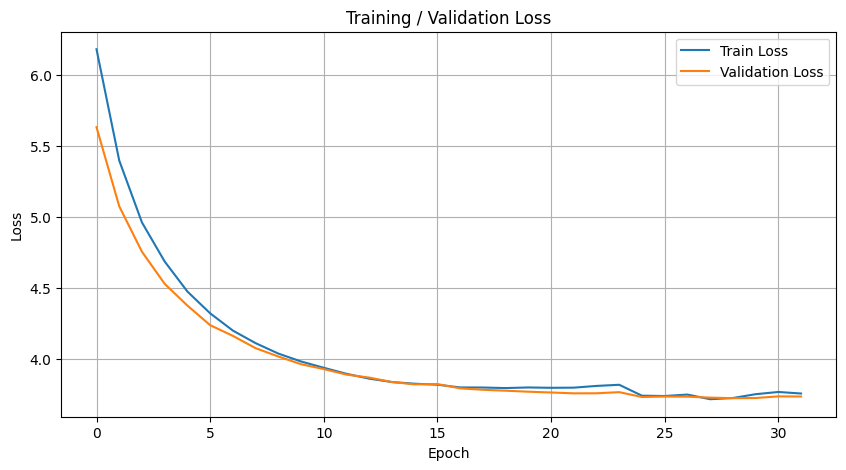

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    history["train"],
    label="Train Loss"
)

plt.plot(
    history["val"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training / Validation Loss")

plt.legend()
plt.grid()

plt.show()

In [ ]:
@torch.no_grad()
def translate(
    model,
    arabic_sentence,
    max_len=30
):

    model.eval()

    normalized = normalize_arabic(arabic_sentence)

    # src_vocab is now SentencePiece-backed: encode the raw normalized
    # string directly (it does its own subword tokenization). We keep
    # the subword pieces separately just for the attention-plot labels.
    src_ids = src_vocab.encode(
        normalized,
        add_sos=False,
        add_eos=True
    )

    tokens = [
        piece.replace("\u2581", " ").strip()
        for piece in src_vocab.encode_pieces(normalized)
    ]

    src = torch.tensor(
        [src_ids],
        dtype=torch.long,
        device=device
    )

    src_lens = torch.tensor(
        [len(src_ids)],
        dtype=torch.long
    )

    src_mask = (
        src != Vocab.PAD
    )

    enc_outputs, hidden = model.encoder(
        src,
        src_lens
    )

    input_step = torch.tensor(
        [Vocab.SOS],
        dtype=torch.long,
        device=device
    )

    generated = []
    attention_weights = []

    for _ in range(max_len):

        logits, hidden, attn = model.decoder(
            input_step,
            hidden,
            enc_outputs,
            src_mask
        )

        pred = logits.argmax(-1).item()

        if pred == Vocab.EOS:
            break

        generated.append(pred)

        attention_weights.append(
            attn[0].cpu().numpy()
        )

        input_step = torch.tensor(
            [pred],
            dtype=torch.long,
            device=device
        )

    translation = tgt_vocab.decode(
        generated
    )

    return (
        translation,
        np.array(attention_weights),
        tokens
    )


In [ ]:
def show_attention(
    arabic_sentence
):

    translation, attention, src_tokens = translate(
        model,
        arabic_sentence
    )

    tgt_tokens = translation.split()

    plt.figure(
        figsize=(12, 7)
    )

    plt.imshow(
        attention,
        aspect="auto"
    )

    fixed_tokens = [fix_arabic_display(tok) for tok in src_tokens]
    plt.xticks(range(len(fixed_tokens)), fixed_tokens, rotation=45, ha="right")

    plt.yticks(
        range(len(tgt_tokens)),
        tgt_tokens
    )

    plt.xlabel(
        "Arabic Source Words"
    )

    plt.ylabel(
        "English Generated Words"
    )

    plt.title(
        "Bahdanau Attention Weights"
    )

    plt.colorbar(
        label="Attention Weight"
    )

    plt.tight_layout()
    plt.show()

    print("Arabic :", arabic_sentence)
    print("English:", translation)

In [ ]:
@torch.no_grad()
def predict_dataset(
    model,
    dataset_path
):

    references = []
    hypotheses = []

    with open(
        dataset_path,
        "r",
        encoding="utf-8"
    ) as f:

        for line in tqdm(
            f,
            desc="Translating Test Set"
        ):

            ar, en = line.rstrip(
                "\n"
            ).split("\t")

            prediction, _, _ = translate(
                model,
                ar
            )

            references.append(en)
            hypotheses.append(
                prediction
            )

    return references, hypotheses

In [ ]:
def detokenize_en(text):
    """Undo the space-padding around punctuation added by normalize_english,
    so sacrebleu scores natural (not pre-tokenized) text as intended."""
    text = re.sub(r"\s+([.,!?'])", r"\1", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


references, hypotheses = predict_dataset(
    model,
    TEST_FILE
)

references_detok = [detokenize_en(r) for r in references]
hypotheses_detok = [detokenize_en(h) for h in hypotheses]

bleu = sacrebleu.corpus_bleu(
    hypotheses_detok,
    [references_detok]
)

print(f"Test BLEU: {bleu.score:.2f}")


Translating Test Set: 0it [00:00, ?it/s]

Test BLEU: 23.10


In [ ]:
@torch.no_grad()
def compute_bleu_on_loader(model, dataset_path):

    references = []
    hypotheses = []

    with open(dataset_path, "r", encoding="utf-8") as f:

        for line in tqdm(f, desc="Translating Validation Set"):

            ar, en = line.rstrip("\n").split("\t")

            prediction, _, _ = translate(model, ar)

            references.append(detokenize_en(en))
            hypotheses.append(detokenize_en(prediction))

    bleu = sacrebleu.corpus_bleu(
        hypotheses,
        [references]
    )

    return bleu


val_bleu = compute_bleu_on_loader(
    model,
    VAL_FILE
)

print(f"Validation BLEU: {val_bleu.score:.2f}")


Translating Validation Set: 0it [00:00, ?it/s]

Validation BLEU: 23.23


## Error Analysis

Per-sentence BLEU on the test set, with the worst-scoring examples inspected for common failure patterns (truncation, repetition).

In [ ]:
@torch.no_grad()
def compute_sentence_bleu_table(model, dataset_path):

    rows = []

    with open(dataset_path, "r", encoding="utf-8") as f:

        for line in tqdm(f, desc="Scoring sentences"):

            ar, en = line.rstrip("\n").split("\t")

            prediction, _, _ = translate(model, ar)

            ref = detokenize_en(en)
            hyp = detokenize_en(prediction)

            score = sacrebleu.sentence_bleu(hyp, [ref]).score

            rows.append({
                "arabic": ar,
                "reference": ref,
                "prediction": hyp,
                "bleu": score,
                "ref_len": len(ref.split()),
                "pred_len": len(hyp.split())
            })

    return pd.DataFrame(rows)


error_df = compute_sentence_bleu_table(model, TEST_FILE)

worst = error_df.sort_values("bleu").head(15)

print("=== 15 Worst Translations (lowest sentence BLEU) ===\n")
for _, row in worst.iterrows():
    print(f"AR : {row['arabic']}")
    print(f"REF: {row['reference']}")
    print(f"HYP: {row['prediction']}")
    print(f"BLEU: {row['bleu']:.2f} | ref_len={row['ref_len']} pred_len={row['pred_len']}")
    print()


Scoring sentences: 0it [00:00, ?it/s]

=== 15 Worst Translations (lowest sentence BLEU) ===

AR : 85 – 87وبسبب التراخي الحركي فسوف تكتسب بعض البقايا طاقه حركه تكفي لكي تغادر تلك البقايا المجره التي تتبعها تاركه ورائها مجره اقل كثافه بالاجرام .
REF: 85 87because of dynamical relaxation, some objects will gain enough energy to reach galactic escape velocity and depart the galaxy, leaving behind a smaller, denser galaxy.
HYP: 8577 the spends of the remnants of some remnants remembered the movement of the the the remnant remains the
BLEU: 1.49 | ref_len=26 pred_len=19

AR : العدد السعيد هو عدد يحقق الشرط التالي : اذا جمع مربع ارقامه و اعيد القيام بتلك العمليه للنتيجه مره او اكثر بقت في النهايه مستقره و تساوي 1 .
REF: those numbers for which this process ends in 1 are happy numbers, while those that do not end in 1 are unhappy numbers or sad numbers.
HYP: the number of a is the next to the the next year, and the the the process is to be more times more time in the stable and equal
BLEU: 1.63 | ref_len=26 pred_len=29

AR : ستولمن

In [ ]:
def has_repetition(text, n=2):
    tokens = text.split()
    for i in range(len(tokens) - n):
        if tokens[i:i + n] == tokens[i + n:i + 2 * n]:
            return True
    return False


short_preds = (worst["pred_len"] < worst["ref_len"] * 0.5).sum()
repeated = worst["prediction"].apply(has_repetition).sum()

print("Out of the 15 worst test examples:")
print(f" - {short_preds} have predictions under half the reference length (possible truncation / early <eos>)")
print(f" - {repeated} contain a repeated word sequence (possible decoding loop)")
print()
print(f"Overall test BLEU        : {bleu.score:.2f}")
print(f"Mean sentence BLEU (all) : {error_df['bleu'].mean():.2f}")
print(f"Mean sentence BLEU (worst 15): {worst['bleu'].mean():.2f}")


Out of the 15 worst test examples:
 - 1 have predictions under half the reference length (possible truncation / early <eos>)
 - 5 contain a repeated word sequence (possible decoding loop)

Overall test BLEU        : 23.10
Mean sentence BLEU (all) : 24.26
Mean sentence BLEU (worst 15): 2.23


In [ ]:
@torch.no_grad()
def beam_search_translate(
    model,
    arabic_sentence,
    beam_width=5,
    max_len=30,
    length_penalty=0.7
):
    model.eval()

    # src_vocab is SentencePiece-backed: encode the raw normalized string
    # directly instead of a pre-tokenized word list.
    normalized = normalize_arabic(arabic_sentence)
    src_ids = src_vocab.encode(normalized, add_sos=False, add_eos=True)

    src = torch.tensor([src_ids], dtype=torch.long, device=device)
    src_lens = torch.tensor([len(src_ids)], dtype=torch.long)
    src_mask = (src != Vocab.PAD)

    enc_outputs, hidden = model.encoder(src, src_lens)

    # each beam: (token_id_sequence, cumulative_log_prob, hidden_state)
    beams = [([Vocab.SOS], 0.0, hidden)]
    completed = []

    for _ in range(max_len):
        candidates = []

        for seq, score, hid in beams:
            if seq[-1] == Vocab.EOS:
                completed.append((seq, score))
                continue

            input_step = torch.tensor([seq[-1]], dtype=torch.long, device=device)
            logits, hid_new, _ = model.decoder(input_step, hid, enc_outputs, src_mask)
            log_probs = torch.log_softmax(logits, dim=-1).squeeze(0)

            topk_log_probs, topk_ids = log_probs.topk(beam_width)

            for lp, idx in zip(topk_log_probs.tolist(), topk_ids.tolist()):
                candidates.append((seq + [idx], score + lp, hid_new))

        if not candidates:
            break

        candidates.sort(key=lambda b: b[1] / (len(b[0]) ** length_penalty), reverse=True)
        beams = candidates[:beam_width]

        if all(seq[-1] == Vocab.EOS for seq, _, _ in beams):
            completed.extend([(seq, score) for seq, score, _ in beams])
            break

    if not completed:
        completed = [(seq, score) for seq, score, _ in beams]

    best_seq, _ = max(completed, key=lambda x: x[1] / (len(x[0]) ** length_penalty))
    generated = [t for t in best_seq if t not in (Vocab.SOS, Vocab.EOS)]

    return tgt_vocab.decode(generated)


In [ ]:
@torch.no_grad()
def evaluate_beam_search_bleu(model, dataset_path, beam_width=5):
    references = []
    hypotheses = []

    with open(dataset_path, "r", encoding="utf-8") as f:
        for line in tqdm(f, desc="Beam Search Translating"):
            ar, en = line.rstrip("\n").split("\t")
            prediction = beam_search_translate(model, ar, beam_width=beam_width)

            references.append(detokenize_en(en))
            hypotheses.append(detokenize_en(prediction))

    return sacrebleu.corpus_bleu(hypotheses, [references])


beam_bleu = evaluate_beam_search_bleu(model, TEST_FILE, beam_width=5)

print(f"Test BLEU (beam search, width=5): {beam_bleu.score:.2f}")
print(f"Test BLEU (greedy, from earlier): {bleu.score:.2f}")

Beam Search Translating: 0it [00:00, ?it/s]

Test BLEU (beam search, width=5): 25.63
Test BLEU (greedy, from earlier): 23.10


In [ ]:
!pip -q install arabic_reshaper python-bidi

import arabic_reshaper
from bidi.algorithm import get_display

def fix_arabic_display(text):
    reshaped = arabic_reshaper.reshape(text)
    return get_display(reshaped)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 10.8 MB/s eta 0:00:00


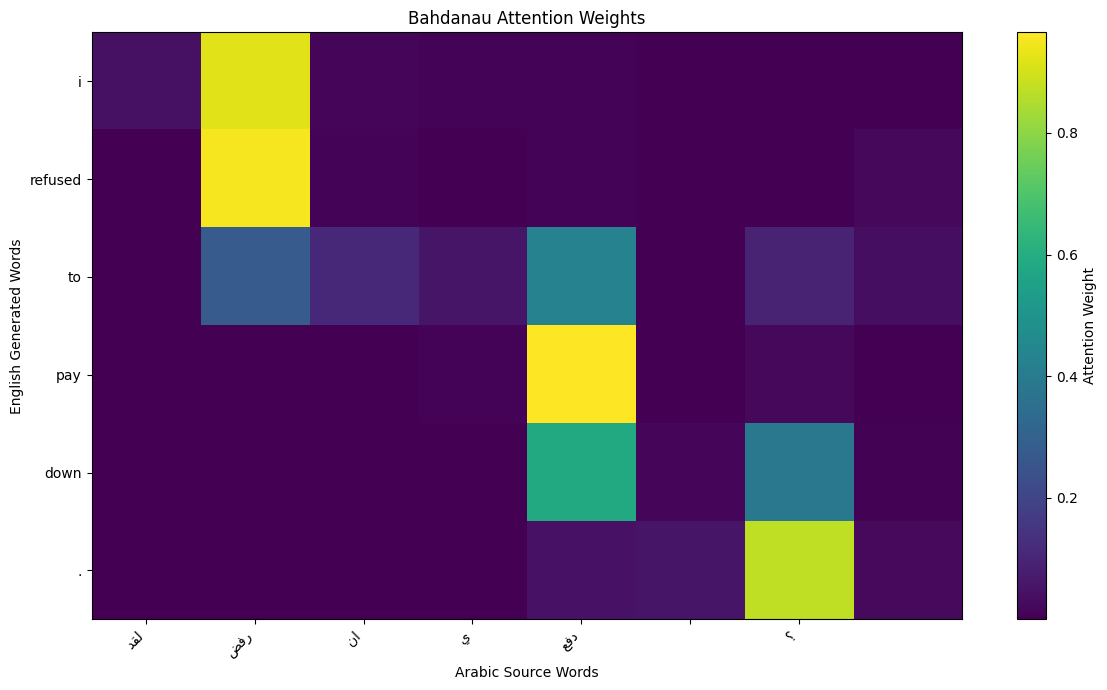

Arabic : لقد رفض ان يدفع ؟
English: i refused to pay down .


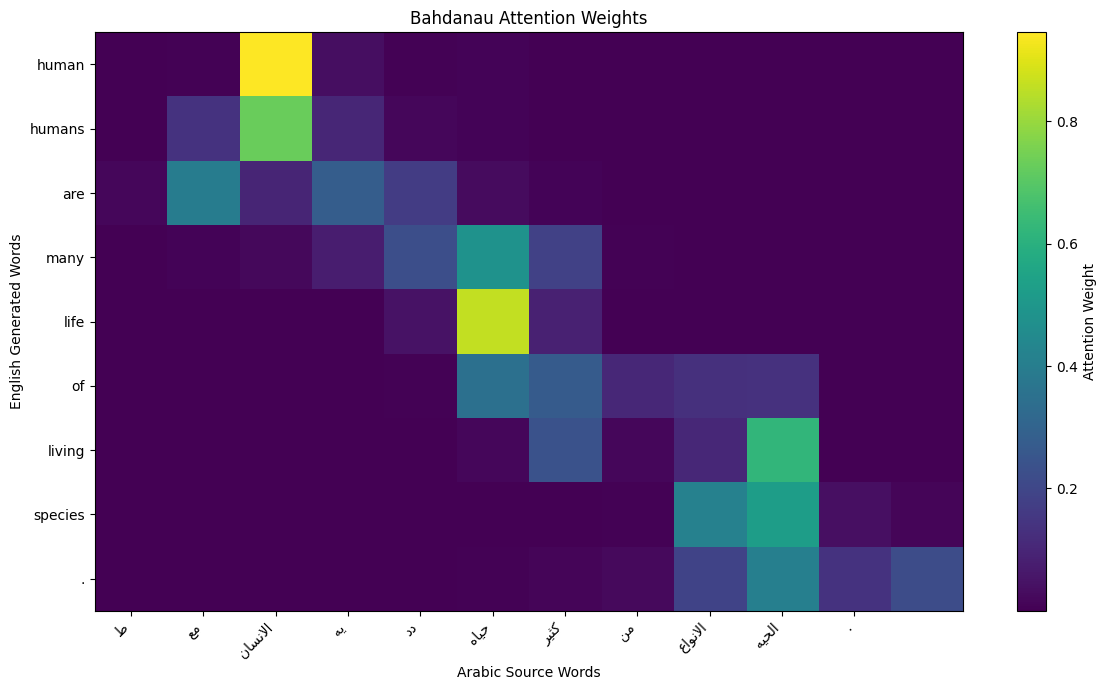

Arabic : طمع الانسان يهدد حياه كثير من الانواع الحيه .
English: human humans are many life of living species .


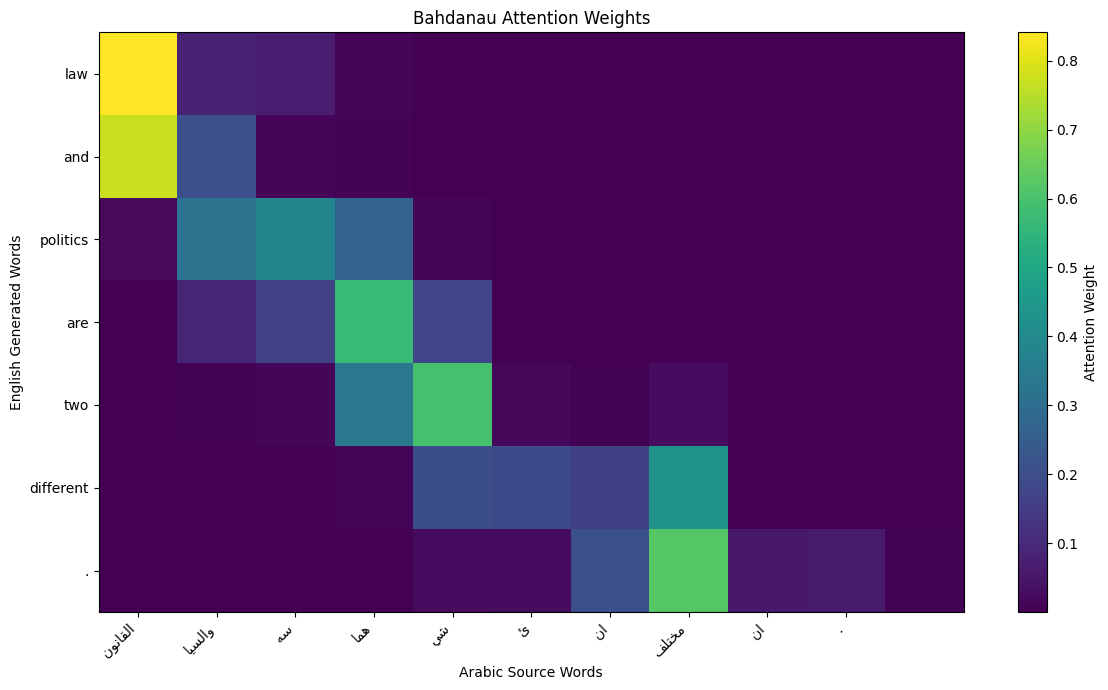

Arabic : القانون والسياسه هما شيئان مختلفان .
English: law and politics are two different .


In [ ]:
# Attention weight visualization for a few sample sentences
sample_sentences = [
    "لقد رفض ان يدفع ؟",
    "طمع الانسان يهدد حياه كثير من الانواع الحيه .",
    "القانون والسياسه هما شيئان مختلفان .",
]

for sent in sample_sentences:
    show_attention(sent)

In [ ]:
best = error_df.sort_values("bleu", ascending=False).head(10)

print("=== Top 10 Best Translations (highest sentence BLEU) ===\n")
for _, row in best.iterrows():
    print(f"AR : {row['arabic']}")
    print(f"REF: {row['reference']}")
    print(f"HYP: {row['prediction']}")
    print(f"BLEU: {row['bleu']:.2f} | ref_len={row['ref_len']} pred_len={row['pred_len']}")
    print()

=== Top 10 Best Translations (highest sentence BLEU) ===

AR : يقدر عدد سكانها ب 1 , 692 نسمه .
REF: the population was 1, 692 at the 2010 census.
HYP: the population was 1, 692 at the 2010 census.
BLEU: 100.00 | ref_len=9 pred_len=9

AR : مقاطعه الك هي احدي مقاطعات ولايه بنسيلفانيا في الولايات المتحده .
REF: elk county is a county located in the u. s. state of pennsylvania.
HYP: elk county is a county located in the u. s. state of pennsylvania.
BLEU: 100.00 | ref_len=13 pred_len=13

AR : يقدر عدد سكانها ب 1 , 043 نسمه .
REF: the population was 1, 043 at the 2010 census.
HYP: the population was 1, 043 at the 2010 census.
BLEU: 100.00 | ref_len=9 pred_len=9

AR : 304 – 308 .
REF: 304 308.
HYP: 304 308.
BLEU: 100.00 | ref_len=2 pred_len=2

AR : فارمنغتون ، مقاطعه واوباكا هي بلده تقع بولايه ويسكونسن في الولايات المتحده .
REF: farmington is a town in waupaca county, wisconsin, united states.
HYP: farmington is a town in waupaca county, wisconsin, united states.
BLEU: 100.00 | ref_len=10 pr

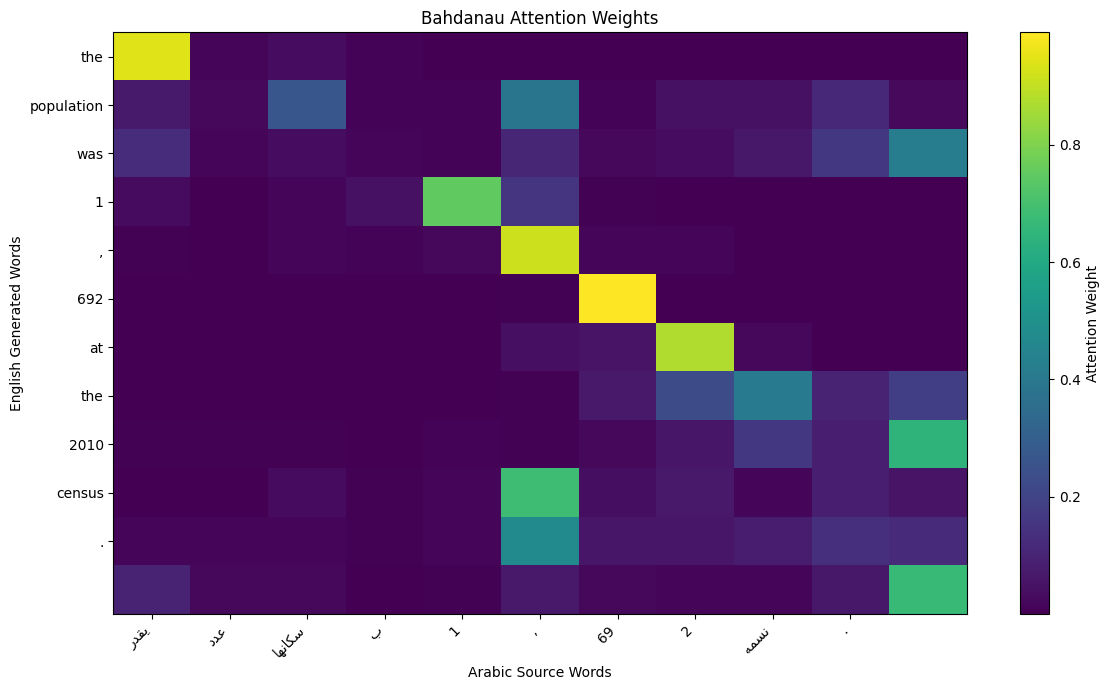

Arabic : يقدر عدد سكانها ب 1 , 692 نسمه .
English: the population was 1 , 692 at the 2010 census .


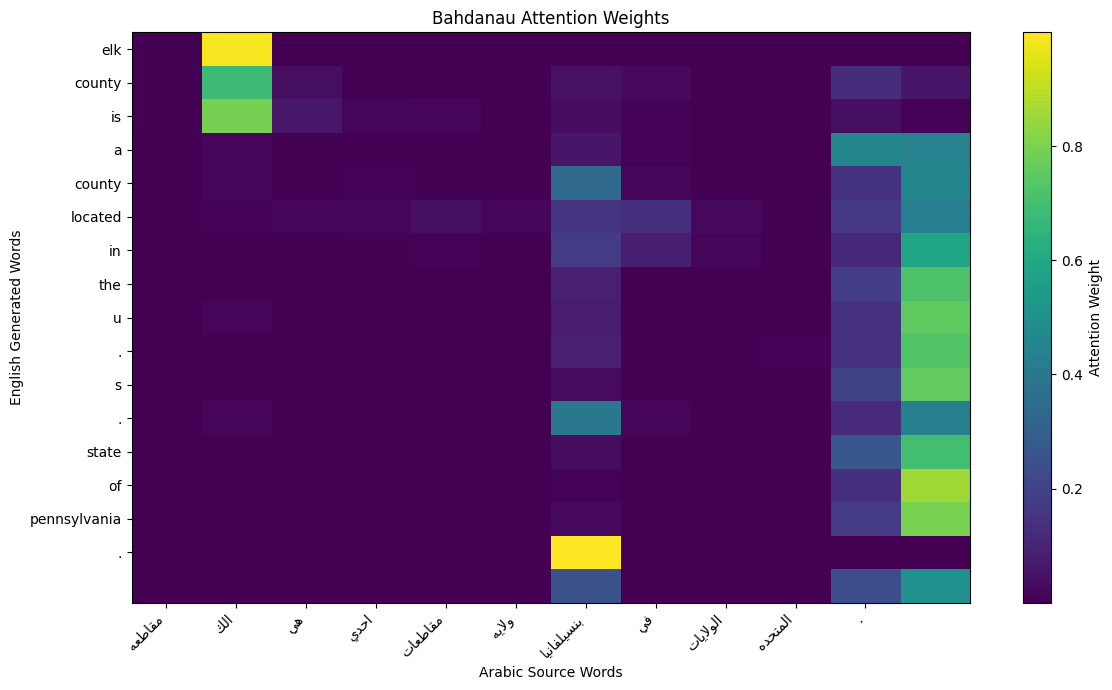

Arabic : مقاطعه الك هي احدي مقاطعات ولايه بنسيلفانيا في الولايات المتحده .
English: elk county is a county located in the u . s . state of pennsylvania .


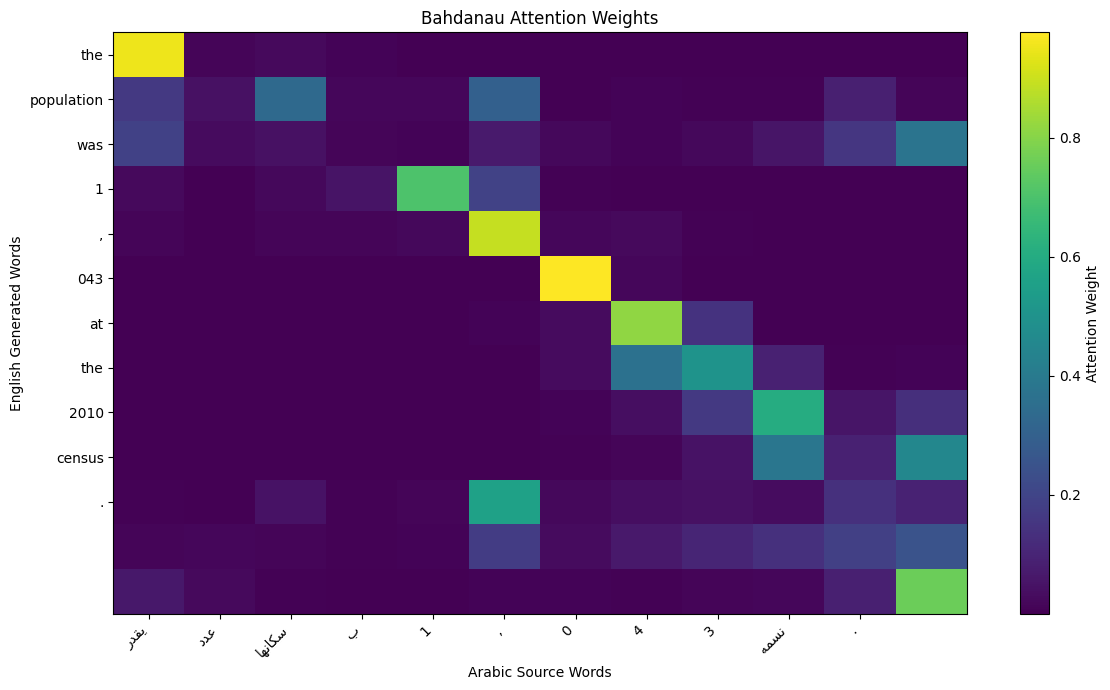

Arabic : يقدر عدد سكانها ب 1 , 043 نسمه .
English: the population was 1 , 043 at the 2010 census .


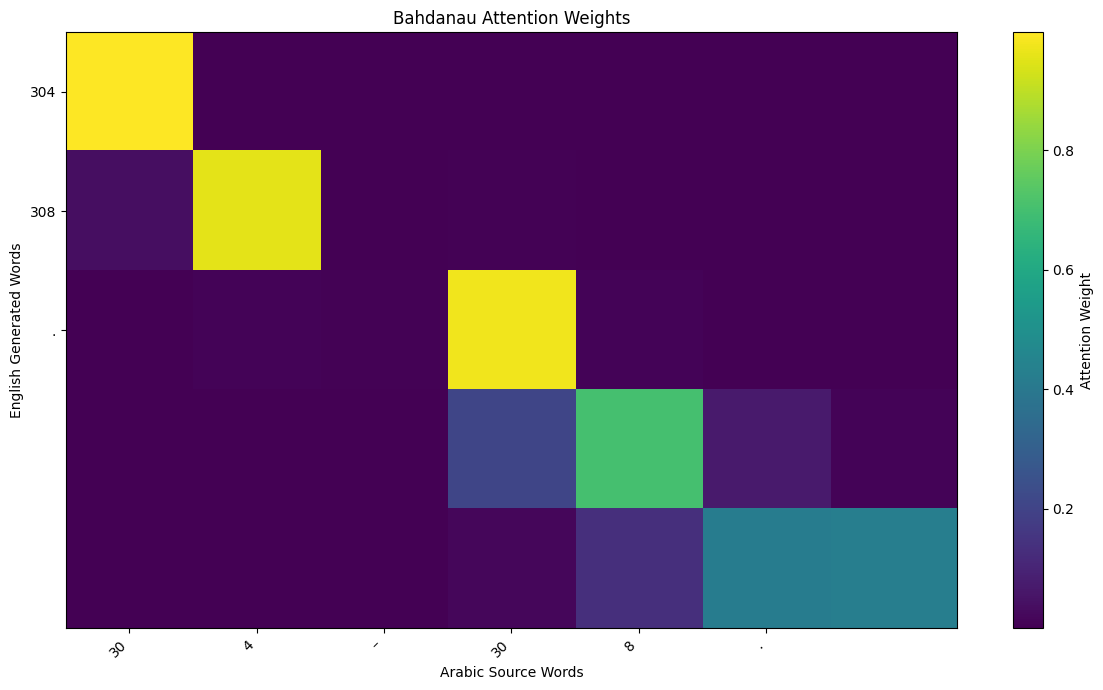

Arabic : 304 – 308 .
English: 304 308 .


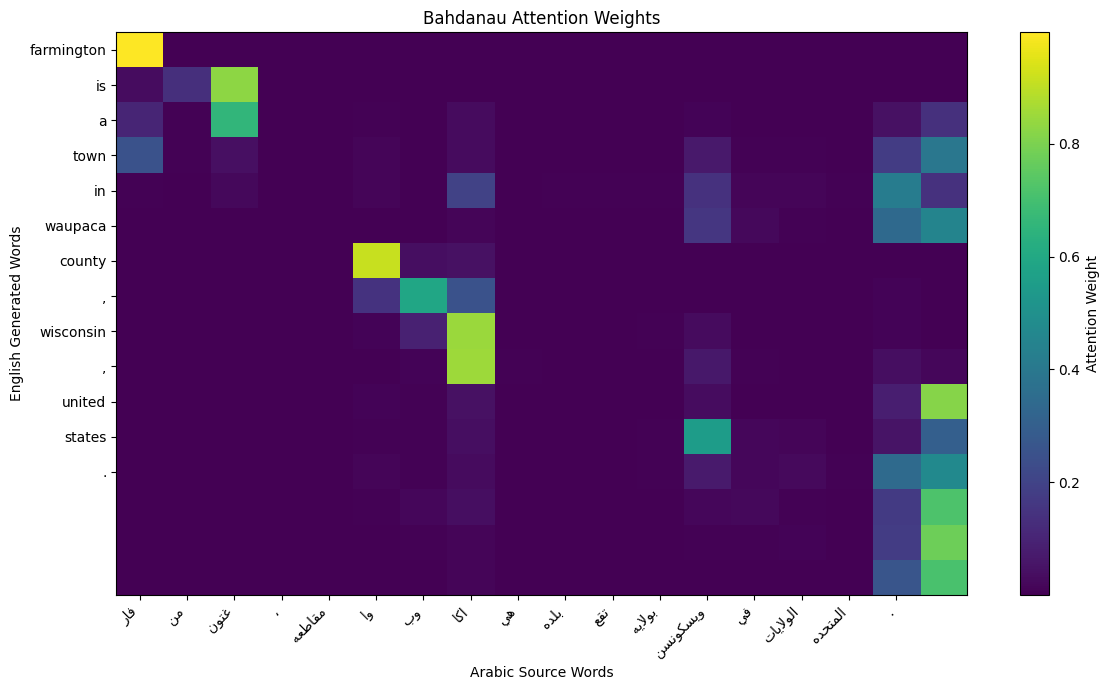

Arabic : فارمنغتون ، مقاطعه واوباكا هي بلده تقع بولايه ويسكونسن في الولايات المتحده .
English: farmington is a town in waupaca county , wisconsin , united states .


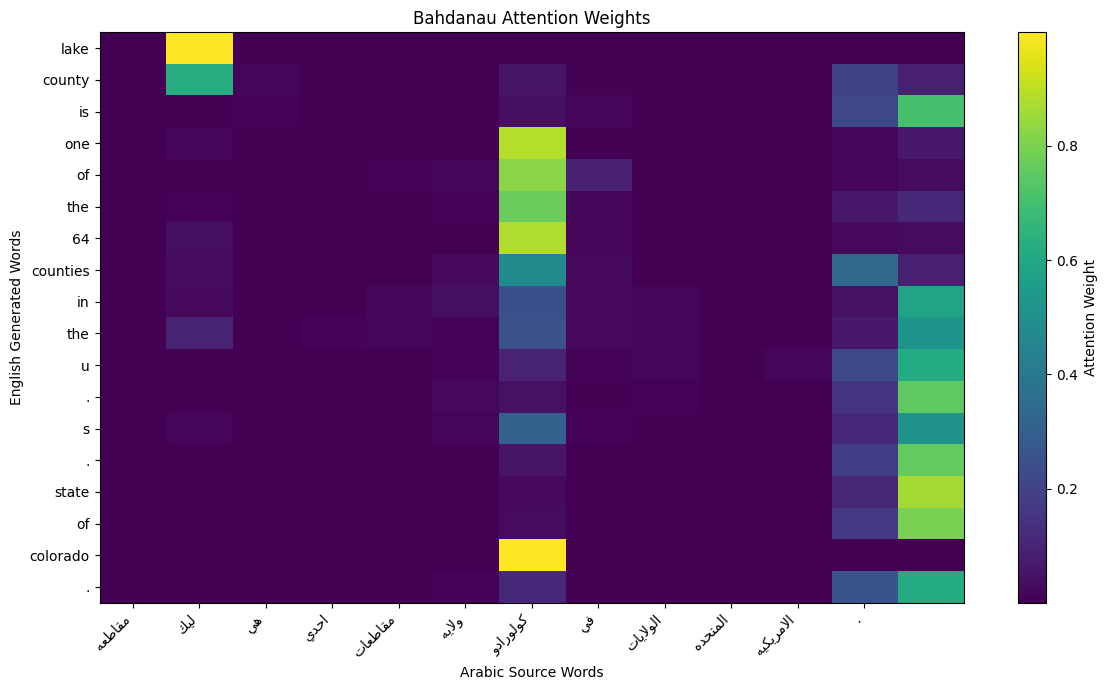

Arabic : مقاطعه ليك هي احدي مقاطعات ولايه كولورادو في الولايات المتحده الامريكيه .
English: lake county is one of the 64 counties in the u . s . state of colorado .


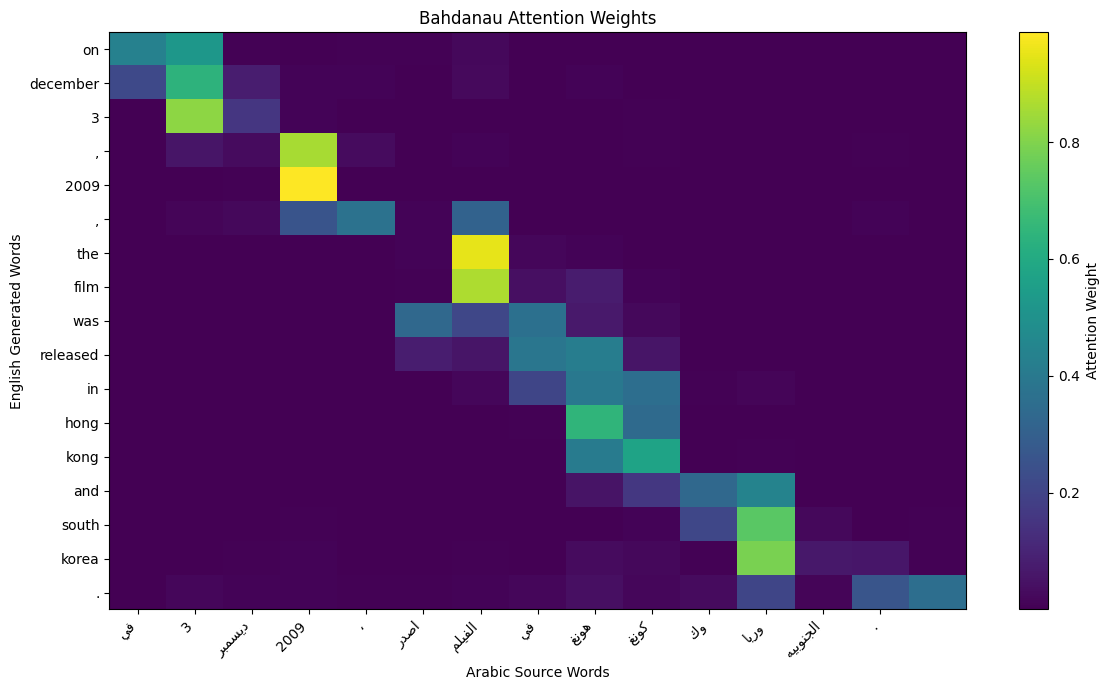

Arabic : في 3 ديسمبر 2009 ، اصدر الفيلم في هونغ كونغ وكوريا الجنوبيه .
English: on december 3 , 2009 , the film was released in hong kong and south korea .


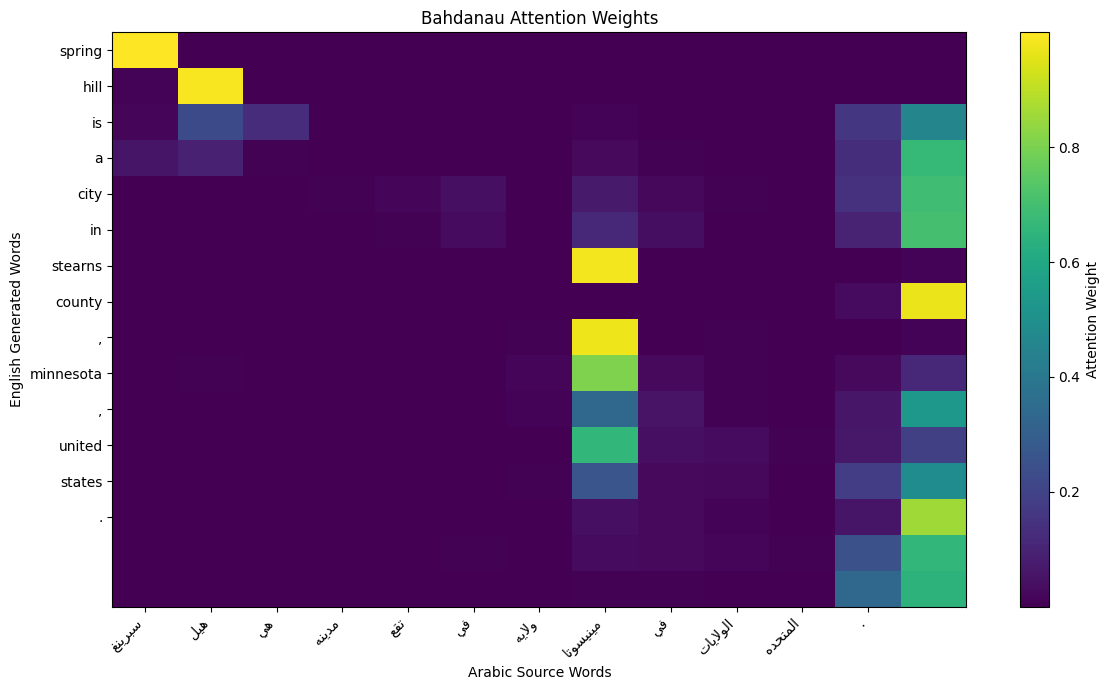

Arabic : سبرينغ هيل هي مدينه تقع في ولايه مينيسوتا في الولايات المتحده .
English: spring hill is a city in stearns county , minnesota , united states .


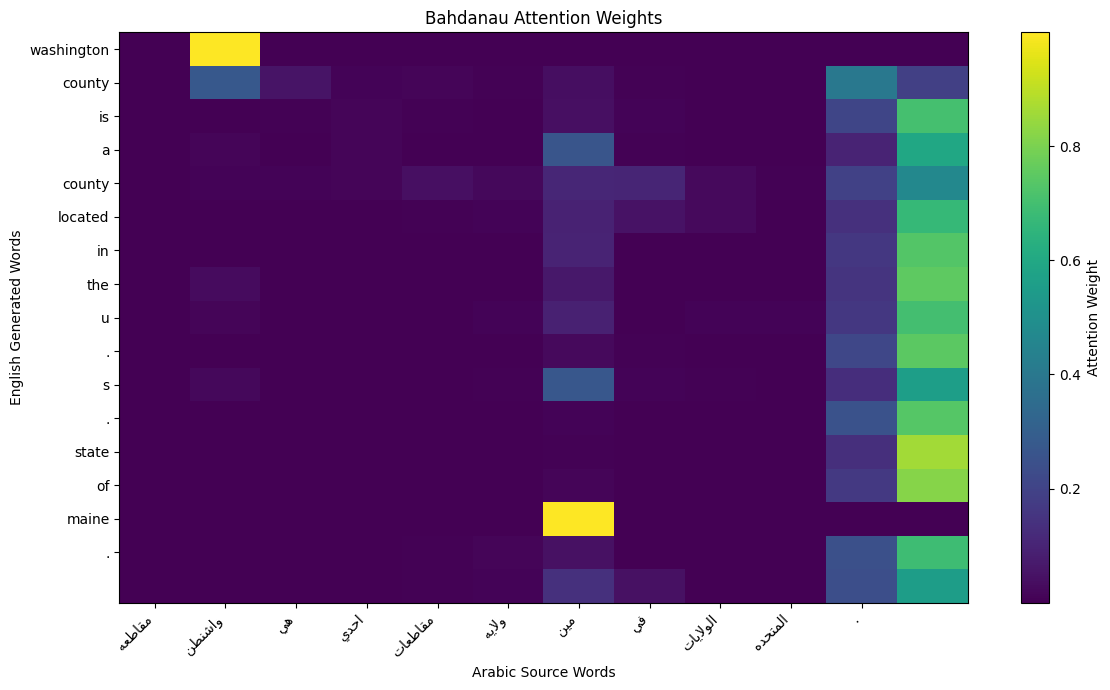

Arabic : مقاطعه واشنطن هي احدي مقاطعات ولايه مين في الولايات المتحده .
English: washington county is a county located in the u . s . state of maine .


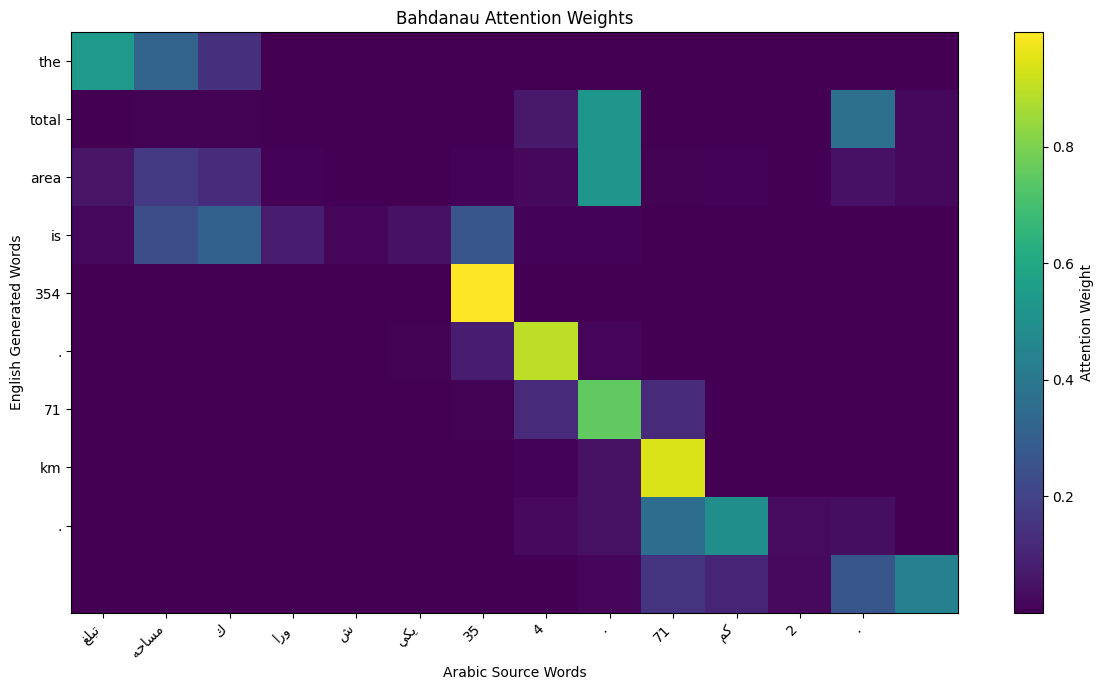

Arabic : تبلغ مساحه كوراشيكي 354 . 71 كم2 .
English: the total area is 354 . 71 km .


In [ ]:
for sent in best["arabic"]:
    show_attention(sent)